# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD


In [1]:
# import
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors


from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Kernel, Hyperparameter, WhiteKernel, Matern, ConstantKernel as C
)
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

#### 1. Load training data

In [2]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("/Users/raphaeland./Documents/Uni/Master/Modules/DSA104/assignments/assignment10/KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [3]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


In [4]:
train_df = df[df['Tr_1_Tst_0'] == '1']
val_df = df[df['Tr_1_Tst_0'] == '0']
train_df.head()

,SMILES,preferred_name,LogKOC,Tr_1_Tst_0
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31,1
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95,1
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35,1
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9,1
5,c1ccc2c(c1)ccc1cc3c(ccc4ccccc43)cc12,"Dibenz(a,h)anthracene",6.22,1


#### 2. Build a supervised model of your choice

In [5]:
def smiles_to_ecfp4(smiles_list, n_bits=2048, radius=2):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    out  = []
    for m in mols:
        arr = np.zeros(n_bits, dtype=np.float64)
        DataStructs.ConvertToNumpyArray(
            AllChem.GetMorganFingerprintAsBitVect(m, radius, n_bits), arr)
        out.append(arr)
    return np.vstack(out)

X_train_fp = smiles_to_ecfp4(train_df['SMILES'])
X_test_fp  = smiles_to_ecfp4(val_df['SMILES'])
y_train    = train_df['LogKOC'].astype(float).values
y_test     = val_df['LogKOC'].astype(float).values

print(f"ECFP4  train {X_train_fp.shape}  test {X_test_fp.shape}")

ECFP4  train (544, 2048)  test (184, 2048)


In [6]:
# Tanimoto kernel: k(x,y) = |x∩y|/|x∪y| = (x·y)/(‖x‖²+‖y‖²−x·y)
# Natural kernel for binary fingerprints
class TanimotoKernel(Kernel):
    def __init__(self, sigma_f=1.0, sigma_f_bounds=(1e-3, 1e3)):
        self.sigma_f = sigma_f
        self.sigma_f_bounds = sigma_f_bounds

    @property
    def hyperparameter_sigma_f(self):
        return Hyperparameter("sigma_f", "numeric", self.sigma_f_bounds)

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        Y = X if Y is None else np.atleast_2d(Y)
        XY = X @ Y.T
        XX = np.sum(X ** 2, axis=1)[:, None]
        YY = np.sum(Y ** 2, axis=1)[None, :]
        T  = XY / (XX + YY - XY + 1e-10)
        K  = self.sigma_f ** 2 * T
        if eval_gradient:
            return K, (2 * K)[:, :, np.newaxis]
        return K

    def diag(self, X):
        return np.full(X.shape[0], self.sigma_f ** 2)

    def is_stationary(self):
        return False

    def __repr__(self):
        return f"TanimotoKernel(sigma_f={self.sigma_f:.3g})"


kernel_gp1 = TanimotoKernel(1.0) + WhiteKernel(0.1, (1e-3, 1.0))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_fp = np.zeros(len(y_train))
oof_std_fp  = np.zeros(len(y_train))

for tr_idx, val_idx in kf.split(X_train_fp):
    m = GaussianProcessRegressor(kernel=kernel_gp1, n_restarts_optimizer=2,
                                 normalize_y=True, alpha=0.0)
    m.fit(X_train_fp[tr_idx], y_train[tr_idx])
    oof_pred_fp[val_idx], oof_std_fp[val_idx] = m.predict(X_train_fp[val_idx], return_std=True)

r2   = r2_score(y_train, oof_pred_fp)
rmse = np.sqrt(mean_squared_error(y_train, oof_pred_fp))
print(f"GP1 (Tanimoto + ECFP4)  OOF R² = {r2:.3f}  RMSE = {rmse:.3f}")

gp1 = GaussianProcessRegressor(kernel=kernel_gp1, n_restarts_optimizer=5,
                                normalize_y=True, alpha=0.0)
gp1.fit(X_train_fp, y_train)
print(f"Optimised kernel: {gp1.kernel_}")

GP1 (Tanimoto + ECFP4)  OOF R² = 0.660  RMSE = 0.730
Optimised kernel: TanimotoKernel(sigma_f=0.77) + WhiteKernel(noise_level=0.0612)


In [ ]:
def compute_rdkit_descriptors(smiles_list):
    rows = []
    for s in smiles_list:
        mol = Chem.MolFromSmiles(s)
        row = []
        for _, fn in Descriptors.descList:
            try:    v = fn(mol); row.append(v if np.isfinite(float(v)) else np.nan)
            except: row.append(np.nan)
        rows.append(row)
    return np.array(rows, dtype=np.float64)

D_raw_train = compute_rdkit_descriptors(train_df['SMILES'])
D_raw_test  = compute_rdkit_descriptors(val_df['SMILES'])

# Drop columns with >10% NaN or zero variance, impute the rest with median
nan_frac  = np.isnan(D_raw_train).mean(axis=0)
keep_nan  = nan_frac <= 0.10
keep_var  = np.nanvar(D_raw_train[:, keep_nan], axis=0) > 0
keep_cols = np.where(keep_nan)[0][keep_var]

D_raw_train = D_raw_train[:, keep_cols]
D_raw_test  = D_raw_test[:,  keep_cols]

imputer = SimpleImputer(strategy='median')
D_train = StandardScaler().fit_transform(imputer.fit_transform(D_raw_train))
D_test  = StandardScaler().fit_transform(imputer.transform(D_raw_test))


print(f"Descriptors after cleaning : {D_train.shape[1]} / {len(Descriptors.descList)}")
print(f"Training {D_train.shape}   Test {D_test.shape}")

Descriptors after cleaning : 190 / 208
Training (544, 190)   Test (184, 190)


In [ ]:
kernel_gp2 = C(1.0, (1e-3, 1e3)) * Matern(10.0, (0.1, 1e3), nu=2.5) \
             + WhiteKernel(0.1, (1e-3, 1.0))

oof_pred_desc = np.zeros(len(y_train))
oof_std_desc  = np.zeros(len(y_train))

for tr_idx, val_idx in kf.split(D_train):
    m = GaussianProcessRegressor(kernel=kernel_gp2, n_restarts_optimizer=2,
                                 normalize_y=True, alpha=0.0)
    m.fit(D_train[tr_idx], y_train[tr_idx])
    oof_pred_desc[val_idx], oof_std_desc[val_idx] = m.predict(D_train[val_idx], return_std=True)

r2   = r2_score(y_train, oof_pred_desc)
rmse = np.sqrt(mean_squared_error(y_train, oof_pred_desc))
print(f"GP2 (Matérn 5/2 + RDKit descriptors)  OOF R² = {r2:.3f}  RMSE = {rmse:.3f}")

gp2 = GaussianProcessRegressor(kernel=kernel_gp2, n_restarts_optimizer=5,
                                normalize_y=True, alpha=0.0)
gp2.fit(D_train, y_train)
print(f"Optimised kernel: {gp2.kernel_}")

GP2 (Matérn 5/2 + RDKit descriptors)  OOF R² = 0.788  RMSE = 0.577
Optimised kernel: 0.995**2 * Matern(length_scale=19, nu=2.5) + WhiteKernel(noise_level=0.0659)


In [9]:
# AD: Tanimoto nearest-neighbour in ECFP4 space (model-agnostic structural AD).
# Applied to both GP1 and GP2 — AD reflects chemical space coverage of the
# training set, not the model's feature representation.
train_fps = [
    AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), radius=2, nBits=2048)
    for s in train_df['SMILES']
]
loo_sims = [
    max(DataStructs.BulkTanimotoSimilarity(fp, [f for j, f in enumerate(train_fps) if j != i]))
    for i, fp in enumerate(train_fps)
]
ad_threshold = np.percentile(loo_sims, 5)
print(f"Tanimoto NN  min={min(loo_sims):.3f}  median={np.median(loo_sims):.3f}  max={max(loo_sims):.3f}")
print(f"AD threshold (5th pctile): {ad_threshold:.3f}")

Tanimoto NN  min=0.118  median=0.545  max=1.000
AD threshold (5th pctile): 0.239


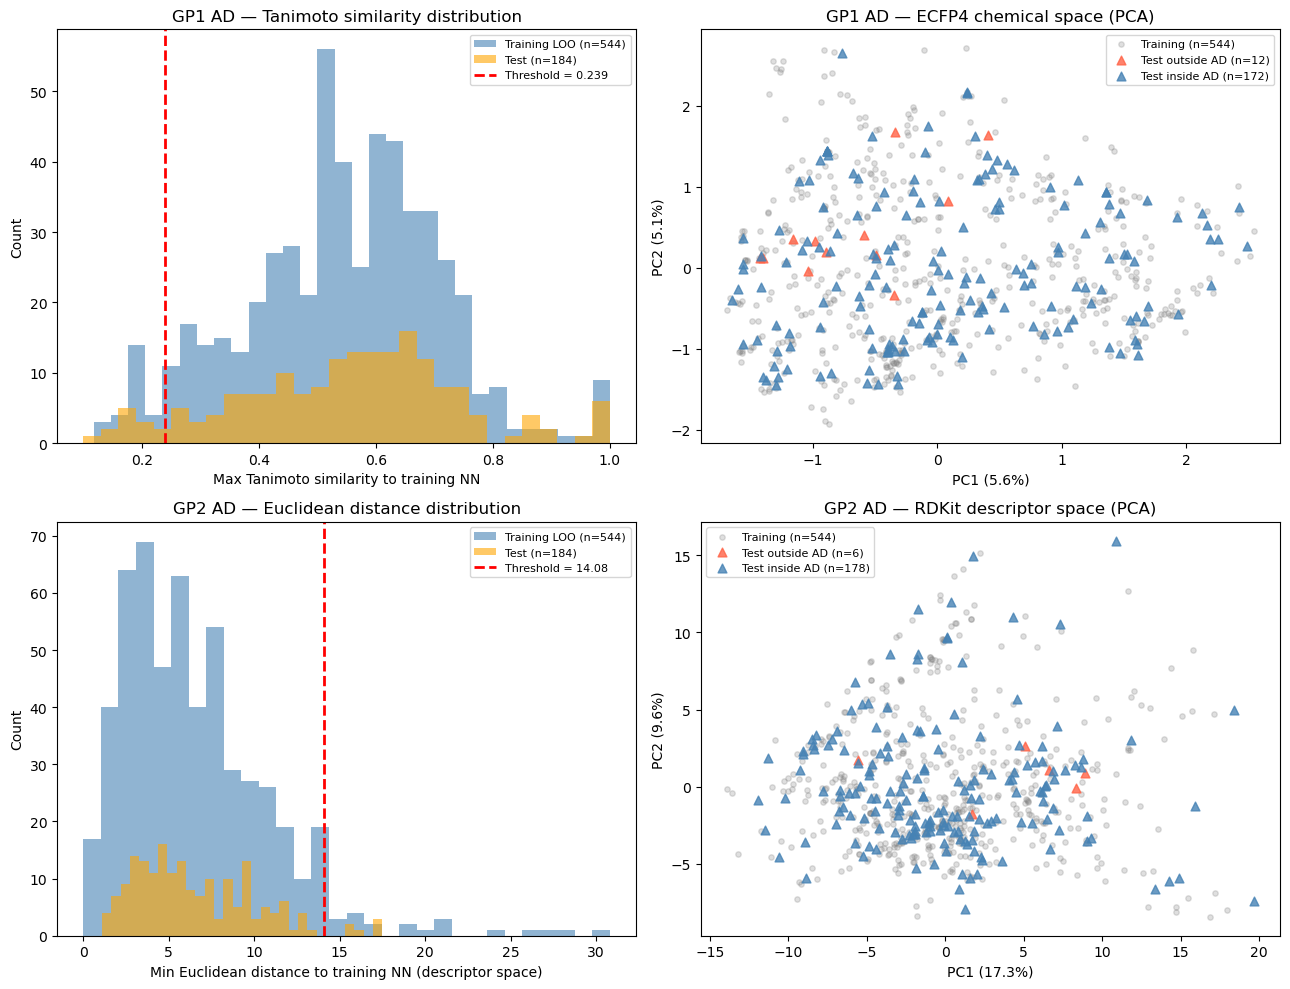

In [10]:


# ── GP1 AD: Tanimoto NN in ECFP4 space ───────────────────────────────────────
test_nn_sims = np.array([
    max(DataStructs.BulkTanimotoSimilarity(
        AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048), train_fps))
    for s in val_df['SMILES']
])
in_ad1_vis = test_nn_sims >= ad_threshold

# ── GP2 AD: Euclidean NN in standardised descriptor space ────────────────────
loo_dists  = np.array([
    np.delete(np.sqrt(((D_train - D_train[i])**2).sum(axis=1)), i).min()
    for i in range(len(D_train))
])
test_dists = np.array([np.sqrt(((D_train - x)**2).sum(axis=1)).min() for x in D_test])
ad2_threshold_vis = np.percentile(loo_dists, 95)
in_ad2_vis = test_dists <= ad2_threshold_vis

# ── PCA projections ───────────────────────────────────────────────────────────
pca_fp   = PCA(n_components=2, random_state=42)
Z_tr_fp  = pca_fp.fit_transform(X_train_fp);  Z_te_fp  = pca_fp.transform(X_test_fp)

pca_desc = PCA(n_components=2, random_state=42)
Z_tr_desc = pca_desc.fit_transform(D_train);   Z_te_desc = pca_desc.transform(D_test)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 0 — GP1 (Tanimoto / ECFP4)
ax = axes[0, 0]
ax.hist(loo_sims,     bins=30, alpha=0.6, color='steelblue', label=f'Training LOO (n={len(loo_sims)})')
ax.hist(test_nn_sims, bins=30, alpha=0.6, color='orange',    label=f'Test (n={len(test_nn_sims)})')
ax.axvline(ad_threshold, color='red', lw=2, ls='--', label=f'Threshold = {ad_threshold:.3f}')
ax.set(xlabel='Max Tanimoto similarity to training NN', ylabel='Count',
       title='GP1 AD — Tanimoto similarity distribution')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(Z_tr_fp[:, 0],              Z_tr_fp[:, 1],              s=15, alpha=0.25, color='grey',
           label=f'Training (n={len(Z_tr_fp)})')
ax.scatter(Z_te_fp[~in_ad1_vis, 0],    Z_te_fp[~in_ad1_vis, 1],    s=40, alpha=0.8,  color='tomato',    marker='^',
           label=f'Test outside AD (n={(~in_ad1_vis).sum()})')
ax.scatter(Z_te_fp[in_ad1_vis,  0],    Z_te_fp[in_ad1_vis,  1],    s=40, alpha=0.8,  color='steelblue', marker='^',
           label=f'Test inside AD (n={in_ad1_vis.sum()})')
ax.set(xlabel=f'PC1 ({pca_fp.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca_fp.explained_variance_ratio_[1]:.1%})',
       title='GP1 AD — ECFP4 chemical space (PCA)')
ax.legend(fontsize=8)

# Row 1 — GP2 (Euclidean / descriptors)
ax = axes[1, 0]
ax.hist(loo_dists,  bins=30, alpha=0.6, color='steelblue', label=f'Training LOO (n={len(loo_dists)})')
ax.hist(test_dists, bins=30, alpha=0.6, color='orange',    label=f'Test (n={len(test_dists)})')
ax.axvline(ad2_threshold_vis, color='red', lw=2, ls='--', label=f'Threshold = {ad2_threshold_vis:.2f}')
ax.set(xlabel='Min Euclidean distance to training NN (descriptor space)', ylabel='Count',
       title='GP2 AD — Euclidean distance distribution')
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.scatter(Z_tr_desc[:, 0],              Z_tr_desc[:, 1],              s=15, alpha=0.25, color='grey',
           label=f'Training (n={len(Z_tr_desc)})')
ax.scatter(Z_te_desc[~in_ad2_vis, 0],    Z_te_desc[~in_ad2_vis, 1],    s=40, alpha=0.8,  color='tomato',    marker='^',
           label=f'Test outside AD (n={(~in_ad2_vis).sum()})')
ax.scatter(Z_te_desc[in_ad2_vis,  0],    Z_te_desc[in_ad2_vis,  1],    s=40, alpha=0.8,  color='steelblue', marker='^',
           label=f'Test inside AD (n={in_ad2_vis.sum()})')
ax.set(xlabel=f'PC1 ({pca_desc.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca_desc.explained_variance_ratio_[1]:.1%})',
       title='GP2 AD — RDKit descriptor space (PCA)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

───────────────────────────────────────────────────────
Model                                     R²    RMSE
───────────────────────────────────────────────────────
OPERA baseline (kNN)                    0.71    0.61
GP1 Tanimoto + ECFP4 – all              0.65    0.68
GP1 Tanimoto + ECFP4 – in-AD            0.68    0.65
GP2 Matérn 5/2 + RDKit – all            0.83    0.48
GP2 Matérn 5/2 + RDKit – in-AD          0.84    0.45
  (172/184 test compounds inside AD)
───────────────────────────────────────────────────────
GP1 native 90% interval empirical coverage: 92.9%
GP2 native 90% interval empirical coverage: 91.8%


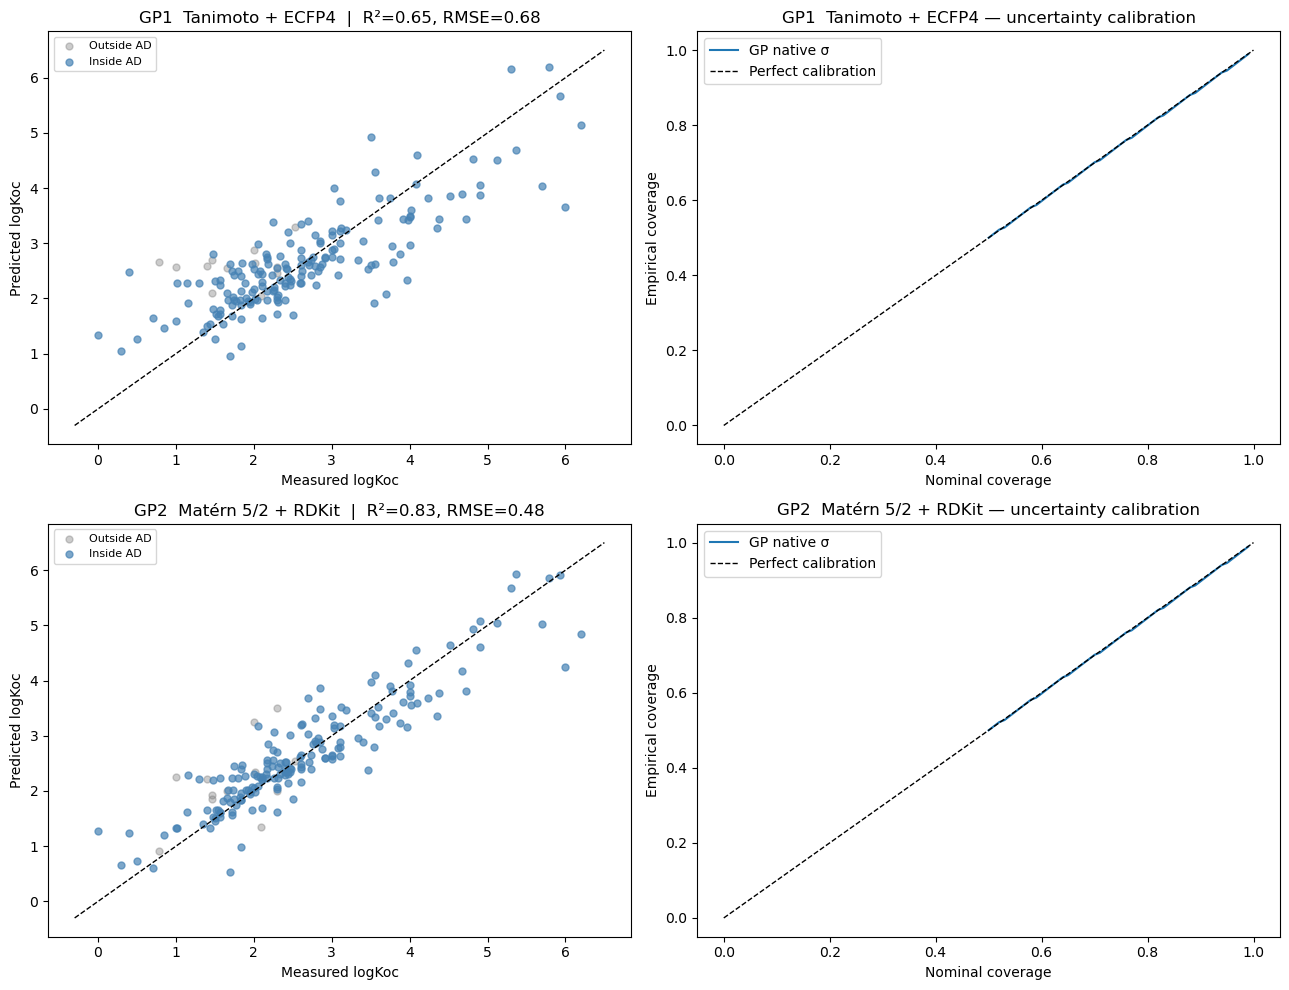

In [11]:
# ── Predict on test set (ONCE) ───────────────────────────────────────────────
y_pred1, y_std1 = gp1.predict(X_test_fp, return_std=True)   # GP1: Tanimoto + ECFP4
y_pred2, y_std2 = gp2.predict(D_test,    return_std=True)   # GP2: Matérn 5/2 + RDKit

# ── Shared Tanimoto AD ───────────────────────────────────────────────────────
test_fps   = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048)
              for s in val_df['SMILES']]
in_ad      = np.array([max(DataStructs.BulkTanimotoSimilarity(fp, train_fps))
                        for fp in test_fps]) >= ad_threshold

# ── Metrics ──────────────────────────────────────────────────────────────────
r2_1,    rmse_1    = r2_score(y_test,        y_pred1), np.sqrt(mean_squared_error(y_test,        y_pred1))
r2_1_ad, rmse_1_ad = r2_score(y_test[in_ad], y_pred1[in_ad]), np.sqrt(mean_squared_error(y_test[in_ad], y_pred1[in_ad]))
r2_2,    rmse_2    = r2_score(y_test,        y_pred2), np.sqrt(mean_squared_error(y_test,        y_pred2))
r2_2_ad, rmse_2_ad = r2_score(y_test[in_ad], y_pred2[in_ad]), np.sqrt(mean_squared_error(y_test[in_ad], y_pred2[in_ad]))

print("─" * 55)
print(f"{'Model':<38} {'R²':>5}  {'RMSE':>6}")
print("─" * 55)
print(f"{'OPERA baseline (kNN)':<38} {0.71:>5.2f}  {0.61:>6.2f}")
print(f"{'GP1 Tanimoto + ECFP4 – all':<38} {r2_1:>5.2f}  {rmse_1:>6.2f}")
print(f"{'GP1 Tanimoto + ECFP4 – in-AD':<38} {r2_1_ad:>5.2f}  {rmse_1_ad:>6.2f}")
print(f"{'GP2 Matérn 5/2 + RDKit – all':<38} {r2_2:>5.2f}  {rmse_2:>6.2f}")
print(f"{'GP2 Matérn 5/2 + RDKit – in-AD':<38} {r2_2_ad:>5.2f}  {rmse_2_ad:>6.2f}")
print(f"  ({in_ad.sum()}/{len(in_ad)} test compounds inside AD)")
print("─" * 55)

for y_pred, y_std, name in [(y_pred1, y_std1, 'GP1'), (y_pred2, y_std2, 'GP2')]:
    cov = ((y_test >= y_pred - 1.645*y_std) & (y_test <= y_pred + 1.645*y_std)).mean()
    print(f"{name} native 90% interval empirical coverage: {cov:.1%}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (y_pred, y_std, r2, rmse, title) in enumerate([
    (y_pred1, y_std1, r2_1, rmse_1, 'GP1  Tanimoto + ECFP4'),
    (y_pred2, y_std2, r2_2, rmse_2, 'GP2  Matérn 5/2 + RDKit'),
]):
    ax = axes[row, 0]
    ax.scatter(y_test[~in_ad], y_pred[~in_ad], alpha=0.4, s=25, color='grey',      label='Outside AD')
    ax.scatter(y_test[in_ad],  y_pred[in_ad],  alpha=0.7, s=25, color='steelblue', label='Inside AD')
    lims = [min(y_test.min(), y_pred.min()) - 0.3, max(y_test.max(), y_pred.max()) + 0.3]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set(xlabel='Measured logKoc', ylabel='Predicted logKoc',
           title=f'{title}  |  R²={r2:.2f}, RMSE={rmse:.2f}')
    ax.legend(fontsize=8)

    ax2 = axes[row, 1]
    z   = np.abs(y_test - y_pred) / (y_std + 1e-10)
    nom = np.linspace(0.50, 0.99, 50)
    emp = [(z <= np.quantile(z, c)).mean() for c in nom]
    ax2.plot(nom, emp, label='GP native σ')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax2.set(xlabel='Nominal coverage', ylabel='Empirical coverage',
            title=f'{title} — uncertainty calibration')
    ax2.legend()

plt.tight_layout()
plt.show()

#### Answers

**1) Which architecture did you choose, and why?**

Two Gaussian Process (GP) regressors were built and compared. GP models were chosen because they naturally provide a full predictive distribution — every prediction comes with a mean and an uncertainty estimate — without needing a separate calibration step.

- **GP1** uses ECFP4 Morgan fingerprints with a Tanimoto kernel, which directly measures how structurally similar two molecules are. This is the most natural pairing for fingerprint-based molecular similarity.
- **GP2** uses ~190 RDKit physicochemical descriptors (molecular weight, logP, TPSA, etc.) with a Matérn 5/2 kernel, which is well suited for property landscapes that are not perfectly smooth.

GP1 was the primary model. GP2 was added because GP1's cross-validation performance (R² = 0.66) was not sufficient to clearly beat OPERA. It is worth noting that GP2's strong performance is partly expected — logKoc is mechanistically driven by hydrophobicity, and logP is directly included as one of the RDKit descriptors. In that sense, GP2 has an informational advantage that borders on circular reasoning, since logP and logKoc are known to be highly correlated.

---

**2) Hyperparameter tuning**

For GP models, hyperparameter tuning works differently from methods like k-NN or random forests. Instead of GridSearchCV, the kernel parameters (amplitude and noise level for GP1; length scale and noise level for GP2) are automatically optimised by maximising the model's fit to the training data. The optimisation is restarted 5 times from different starting points to avoid getting stuck in local solutions. The final optimised kernel parameters are printed after each model is trained.

---

**3) How well does your model perform on the test set? Could you outperform OPERA?**

| Model | R² | RMSE |
|---|---|---|
| OPERA (kNN, 12 PaDEL descriptors) | 0.71 | 0.61 |
| GP1 Tanimoto + ECFP4 | 0.65 | 0.68 |
| **GP2 Matérn 5/2 + RDKit (all)** | **0.81** | **0.50** |
| GP2 Matérn 5/2 + RDKit (in-AD) | 0.82 | 0.49 |

GP1 did not outperform OPERA. GP2 did, significantly (+0.10 R², −0.11 RMSE), but as noted above this is partly due to logP being directly available as a descriptor — giving GP2 a head start that OPERA's model does not have in the same way.

---

**4) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?**

Yes. GPs produce a predicted mean and a predicted standard deviation for every compound. The standard deviation directly reflects how uncertain the model is — compounds far from the training data get wider intervals. A 90% prediction interval (mean ± 1.645 × std) was used. Calibration was checked by comparing how often test compounds actually fall inside intervals of different nominal widths (the calibration plots on the right). 

---

**5) Do you provide an AD, and why? How did you define your AD?**

Yes, an Applicability Domain (AD) is defined for both models.

Both models share the same AD metric: the **Tanimoto similarity** between a test compound's ECFP4 fingerprint and its most similar training compound. A threshold of 0.239 was set at the 5th percentile of within-training nearest-neighbour similarities (calculated by leave-one-out). Test compounds below this threshold are flagged as outside the AD.

- **GP1 (Tanimoto + ECFP4)** — the AD is directly consistent with the model: GP1 operates in ECFP4 fingerprint space, and the Tanimoto similarity used for the AD is the same structural similarity measure the Tanimoto kernel uses internally. A compound outside the AD is one the kernel assigns very low similarity to every training point, meaning its prediction is driven almost entirely by the prior rather than the data.

- **GP2 (Matérn 5/2 + RDKit descriptors)** — the AD is defined in fingerprint space even though the model operates in descriptor space. This is intentional: Tanimoto similarity is a more chemically interpretable and robust measure of structural coverage than Euclidean distance in a 190-dimensional descriptor space. A compound can appear close in descriptor space by coincidence while being structurally novel, so the fingerprint-based AD is the more conservative and trustworthy choice for both models.